# NYC Weather and Traffic Delay Prediction

This notebook builds an API-based data pipeline that combines NYC traffic volume data with weather data, stores the cleaned dataset in MySQL, explores congestion patterns, trains weather-aware delay-risk models, and exports Tableau-ready dashboard tables.


## 1. Environment Setup

Install dependencies if needed, then import the libraries used for API ingestion, data cleaning, visualization, modeling, MySQL storage, and Tableau exports.


In [39]:
# Optional: run once if these packages are missing from your notebook kernel.
%pip install openmeteo-requests requests-cache retry-requests


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
# Optional: run once if these packages are missing from your notebook kernel.
%pip install sqlalchemy pymysql python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Weather API Ingestion

Pull historical weather observations from the Open-Meteo API for New York City. These records become the weather side of the traffic-delay analysis.


In [41]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 40.73061,
	"longitude": -73.935242,
	"start_date": "2020-01-01",
	"end_date": "2025-12-31",
	"daily": [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",   
    "sunrise",
    "sunset"
],
	"hourly": ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature", "precipitation", "rain", "snowfall", "snow_depth", "wind_speed_10m"],
	"timezone": "auto",
	"temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_dew_point_2m = hourly.Variables(2).ValuesAsNumpy()
hourly_apparent_temperature = hourly.Variables(3).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(4).ValuesAsNumpy()
hourly_rain = hourly.Variables(5).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(6).ValuesAsNumpy()
hourly_snow_depth = hourly.Variables(7).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(8).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["dew_point_2m"] = hourly_dew_point_2m
hourly_data["apparent_temperature"] = hourly_apparent_temperature
hourly_data["precipitation"] = hourly_precipitation
hourly_data["rain"] = hourly_rain
hourly_data["snowfall"] = hourly_snowfall
hourly_data["snow_depth"] = hourly_snow_depth
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()

daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_max = daily.Variables(1).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()   # ✅ ADD THIS
daily_sunrise = daily.Variables(4).ValuesInt64AsNumpy()
daily_sunset = daily.Variables(5).ValuesInt64AsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["precipitation"] = daily_precipitation_sum
daily_data["sunrise"] = daily_sunrise
daily_data["sunset"] = daily_sunset
daily_dataframe = pd.DataFrame(data = daily_data)

hourly_dataframe.head()

Coordinates: 40.738136291503906°N -73.91488647460938°E
Elevation: 14.0 m asl
Timezone: b'America/New_York'b'GMT-4'
Timezone difference to GMT+0: -14400s


,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,wind_speed_10m
0,2020-01-01 00:00:00+00:00,39.829998,79.699532,34.070000,32.075100,0.0,0.0,0.0,0.0,10.088845
1,2020-01-01 01:00:00+00:00,38.209999,75.076363,31.010000,29.407892,0.0,0.0,0.0,0.0,11.428421
2,2020-01-01 02:00:00+00:00,35.779999,77.071312,29.299999,26.927099,0.0,0.0,0.0,0.0,10.963583
3,2020-01-01 03:00:00+00:00,34.790001,78.990501,28.940001,26.067801,0.0,0.0,0.0,0.0,10.535296
4,2020-01-01 04:00:00+00:00,34.160000,77.779877,27.950001,24.650108,0.0,0.0,0.0,0.0,12.081872


## 3. Traffic API Ingestion

Pull NYC traffic volume records directly from the NYC Open Data API. The project uses API ingestion instead of CSV files.


In [42]:
import requests
import pandas as pd

url = "https://data.cityofnewyork.us/resource/7ym2-wayt.json?$limit=50000"

response = requests.get(url)
data = response.json()

df_traffic = pd.DataFrame(data)

print(df_traffic.head())
print(df_traffic.columns)

  requestid    boro    yr  m  d hh  mm vol segmentid  \
0     12512  Queens  2013  3  7  4  15   5     55135   
1     12512  Queens  2013  3  7  4  30   8     55135   
2     12512  Queens  2013  3  7  4  45   8     55135   
3     12512  Queens  2013  3  7  5   0   7     55135   
4     12512  Queens  2013  3  7  5  15   9     55135   

                      wktgeom  street     fromst           tost direction  
0  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
1  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
2  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
3  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
4  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
Index(['requestid', 'boro', 'yr', 'm', 'd', 'hh', 'mm', 'vol', 'segmentid',
       'wktgeom', 'street', 'fromst', 'tost', 'direction'],
      dtype='str')


## 4. Clean, Align, and Merge

Standardize date and hour fields, merge traffic and weather records, and create the final modeling table.


In [43]:
hourly_dataframe["date"] = pd.to_datetime(hourly_dataframe["date"])
hourly_dataframe["date"] = hourly_dataframe["date"].dt.tz_localize(None)

hourly_dataframe["date_only"] = hourly_dataframe["date"].dt.date
hourly_dataframe["hour"] = hourly_dataframe["date"].dt.hour

In [44]:
df_traffic["date"] = pd.to_datetime(
    df_traffic["yr"].astype(str) + "-" +
    df_traffic["m"].astype(str) + "-" +
    df_traffic["d"].astype(str)
)

df_traffic["hour"] = df_traffic["hh"].astype(int)
df_traffic["vol"] = pd.to_numeric(df_traffic["vol"], errors="coerce")

df_traffic = df_traffic.dropna(subset=["date", "hour", "vol"])

In [45]:
df_traffic["date"] = pd.to_datetime(df_traffic["date"])
hourly_dataframe["date_only"] = pd.to_datetime(hourly_dataframe["date"].dt.date)

In [46]:
df_merged = pd.merge(
    df_traffic,
    hourly_dataframe,
    left_on=["date", "hour"],
    right_on=["date_only", "hour"],
    how="inner"
)

In [47]:
df_merged = df_merged.rename(columns={"date_x": "date"})

In [48]:
df_final = df_merged[[
    "date",
    "hour",
    "boro",
    "street",
    "fromst",
    "tost",
    "direction",
    "vol",
    "temperature_2m",
    "precipitation"
]].copy()

df_final = df_final.dropna()

In [49]:
# Preview the merged dataset before writing to MySQL.
display(df_final.head())
print(f"Final rows: {len(df_final):,}")


,date,hour,boro,street,fromst,tost,direction,vol,temperature_2m,precipitation
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,45.139999,0.0
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,45.950001,0.0
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,45.950001,0.0
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,45.950001,0.0
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,45.950001,0.0


Final rows: 8,776


## 5. MySQL Storage

Create/connect to the MySQL database and write the API-generated final table. This keeps Tableau and downstream analysis connected to database tables rather than local CSV files.


In [50]:
import os
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

MYSQL_USER = os.getenv("MYSQL_USER", "root")
MYSQL_PASSWORD = quote_plus(os.getenv("MYSQL_PASSWORD", "your_password"))
MYSQL_HOST = os.getenv("MYSQL_HOST", "localhost")
MYSQL_PORT = os.getenv("MYSQL_PORT", "3306")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE", "weather_traffic")

# Connect to MySQL server, not a specific database yet
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/",
    pool_pre_ping=True
)

with server_engine.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE}"))
    conn.commit()

# Now connect to the database you created
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}",
    pool_pre_ping=True
)



In [51]:
df_final.to_sql(
    "weather_traffic_full",
    con=engine,
    if_exists="replace",
    index=False
)

8776

## 6. Exploratory Data Analysis

Explore data quality, traffic patterns, borough differences, weather relationships, and temporal trends before modeling.


In [52]:
import matplotlib.pyplot as plt

eda_df = df_final.copy()
eda_df["date"] = pd.to_datetime(eda_df["date"])
eda_df["vol"] = pd.to_numeric(eda_df["vol"], errors="coerce")
eda_df["temperature_2m"] = pd.to_numeric(eda_df["temperature_2m"], errors="coerce")
eda_df["precipitation"] = pd.to_numeric(eda_df["precipitation"], errors="coerce")
eda_df["day_of_week"] = eda_df["date"].dt.day_name()
eda_df["month"] = eda_df["date"].dt.to_period("M").astype(str)
eda_df["is_raining"] = eda_df["precipitation"] > 0

print(f"Rows: {eda_df.shape[0]:,}")
print(f"Columns: {eda_df.shape[1]:,}")
print(f"Date range: {eda_df['date'].min().date()} to {eda_df['date'].max().date()}")
display(eda_df.head())

Rows: 8,776
Columns: 13
Date range: 2020-01-26 to 2024-06-07


,date,hour,boro,street,fromst,tost,direction,vol,temperature_2m,precipitation,day_of_week,month,is_raining
0,2023-11-15,20,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,20,45.139999,0.0,Wednesday,2023-11,False
1,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,15,45.950001,0.0,Wednesday,2023-11,False
2,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,26,45.950001,0.0,Wednesday,2023-11,False
3,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,23,45.950001,0.0,Wednesday,2023-11,False
4,2023-11-15,21,Brooklyn,AVENUE J,East 80 Street,East 81 Street,EB,13,45.950001,0.0,Wednesday,2023-11,False


In [53]:
overview = pd.DataFrame({
    "dtype": eda_df.dtypes.astype(str),
    "missing_count": eda_df.isna().sum(),
    "missing_pct": (eda_df.isna().mean() * 100).round(2),
    "unique_values": eda_df.nunique()
})

display(overview)
print(f"Duplicate rows: {eda_df.duplicated().sum():,}")
display(eda_df[["vol", "temperature_2m", "precipitation", "hour"]].describe().T)

,dtype,missing_count,missing_pct,unique_values
date,datetime64[us],0,0.0,161
hour,int64,0,0.0,24
boro,str,0,0.0,5
street,str,0,0.0,70
fromst,str,0,0.0,65
tost,str,0,0.0,61
direction,str,0,0.0,4
vol,int64,0,0.0,677
temperature_2m,float32,0,0.0,662
precipitation,float32,0,0.0,45


Duplicate rows: 656


,count,mean,std,min,25%,50%,75%,max
vol,8776.0,112.942457,161.516707,0.000000,17.000000,61.000000,142.000000,1295.000000
temperature_2m,8776.0,55.568874,15.686083,14.450001,44.059998,55.580002,67.910004,90.500000
precipitation,8776.0,0.005353,0.028202,0.000000,0.000000,0.000000,0.000000,0.661417
hour,8776.0,11.311418,6.895309,0.000000,5.000000,11.000000,17.000000,23.000000


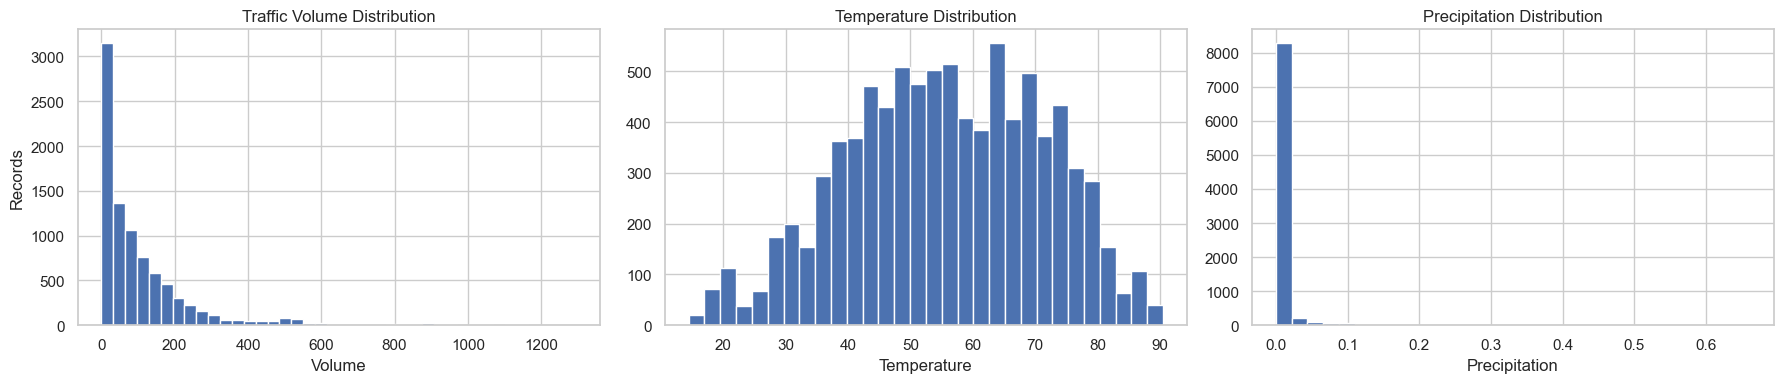

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

eda_df["vol"].hist(bins=40, ax=axes[0])
axes[0].set_title("Traffic Volume Distribution")
axes[0].set_xlabel("Volume")
axes[0].set_ylabel("Records")

eda_df["temperature_2m"].hist(bins=30, ax=axes[1])
axes[1].set_title("Temperature Distribution")
axes[1].set_xlabel("Temperature")

eda_df["precipitation"].hist(bins=30, ax=axes[2])
axes[2].set_title("Precipitation Distribution")
axes[2].set_xlabel("Precipitation")

plt.tight_layout()
plt.show()

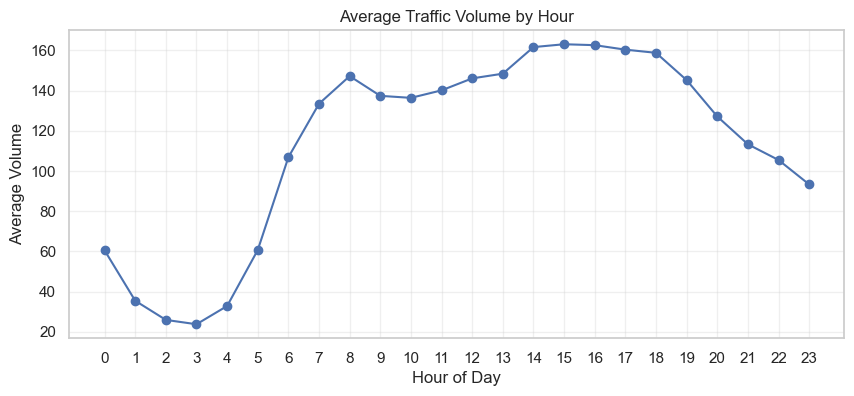

,hour,vol
15,15,163.081232
16,16,162.629526
14,14,161.665738
17,17,160.399433
18,18,158.818713
13,13,148.441489
8,8,147.229111
12,12,146.107612
19,19,145.252226
11,11,140.148936


In [55]:
hourly_pattern = eda_df.groupby("hour", as_index=False)["vol"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_pattern["hour"], hourly_pattern["vol"], marker="o")
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Volume")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

display(hourly_pattern.sort_values("vol", ascending=False).head(10))

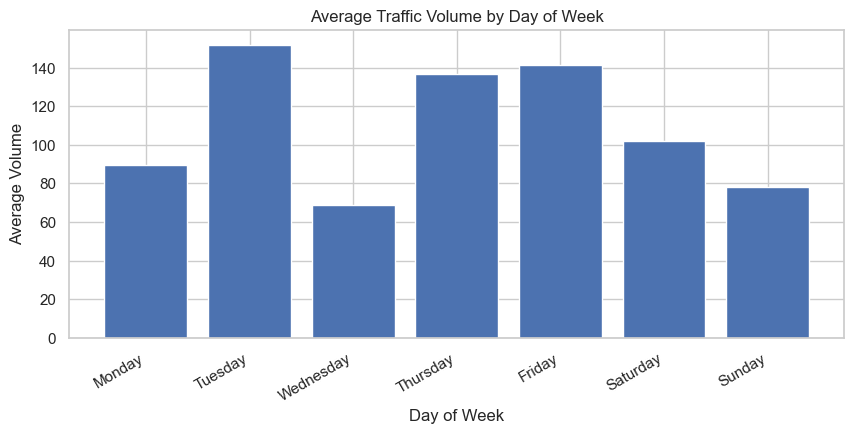

,day_of_week,vol
0,Monday,89.317797
1,Tuesday,151.917834
2,Wednesday,68.658200
3,Thursday,136.588881
4,Friday,141.247605
5,Saturday,102.047809
6,Sunday,78.065217


In [56]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_pattern = eda_df.groupby("day_of_week")["vol"].mean().reindex(day_order).reset_index()

plt.figure(figsize=(10, 4))
plt.bar(day_pattern["day_of_week"], day_pattern["vol"])
plt.title("Average Traffic Volume by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Volume")
plt.xticks(rotation=30, ha="right")
plt.show()

display(day_pattern)

,records,avg_volume,median_volume,max_volume
boro,,,,
Brooklyn,2780,150.629496,79.0,1295
Manhattan,1306,135.843798,127.0,569
Staten Island,315,130.711111,133.0,362
Queens,2586,94.013921,34.0,795
Bronx,1789,61.893236,37.0,263


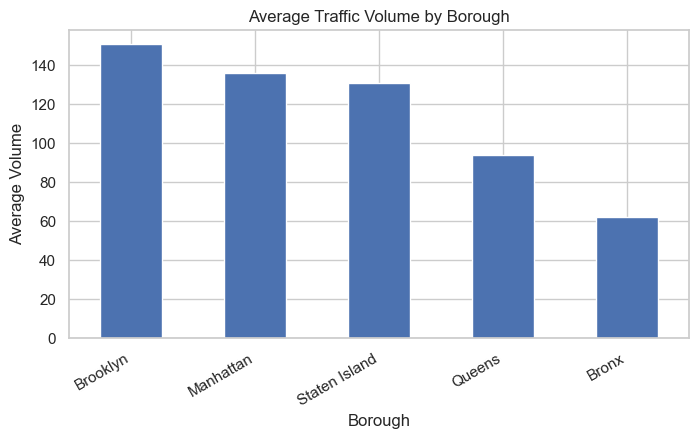

In [57]:
boro_summary = (
    eda_df.groupby("boro")
    .agg(records=("vol", "size"), avg_volume=("vol", "mean"), median_volume=("vol", "median"), max_volume=("vol", "max"))
    .sort_values("avg_volume", ascending=False)
)

display(boro_summary)
boro_summary["avg_volume"].plot(kind="bar", figsize=(8, 4), title="Average Traffic Volume by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Volume")
plt.xticks(rotation=30, ha="right")
plt.show()

In [58]:
street_summary = (
    eda_df.groupby(["boro", "street"])
    .agg(records=("vol", "size"), avg_volume=("vol", "mean"), max_volume=("vol", "max"))
    .query("records >= 5")
    .sort_values("avg_volume", ascending=False)
    .head(15)
)

display(street_summary)

records  avg_volume  max_volume
boro      street                                                           
Brooklyn  BELT PARKWAY                          105  841.133333        1295
          BROOKLYN QUEENS EXPRESSWAY            105  752.076190        1066
Queens    HOOK CREEK BRIDGE                     374  378.390374         682
Manhattan EAST 58 STREET                         23  377.478261         569
Brooklyn  HAMILTON AVENUE                       105  272.180952         740
          GOWANUS EP WB EN HUGH CAREY TNNL      105  270.209524         598
Manhattan AVENUE OF THE AMERICAS                105  263.800000         418
Queens    NORTH CONDUIT AVENUE                   46  252.826087         795
Brooklyn  HAMILTON AVENUE BRIDGE                 71  234.521127         590
          CROPSEY AVENUE                         77  216.740260         371
Queens    BROOKLYN QUEENS EXPRESSWAY             20  215.750000         463
Manhattan 5 AVENUE                              105  214.057143         332
          7 AVENUE                              105  207.676190         309
Bronx     EAST TREMONT AVENUE                    69  183.304348         243
Brooklyn  ATLANTIC AVENUE                       105  178.780952         326

,records,avg_volume,median_volume,avg_temperature,avg_precipitation
is_raining,,,,,
False,7646,113.653675,60.0,55.736092,0.000000
True,1130,108.130088,73.0,54.437401,0.041572


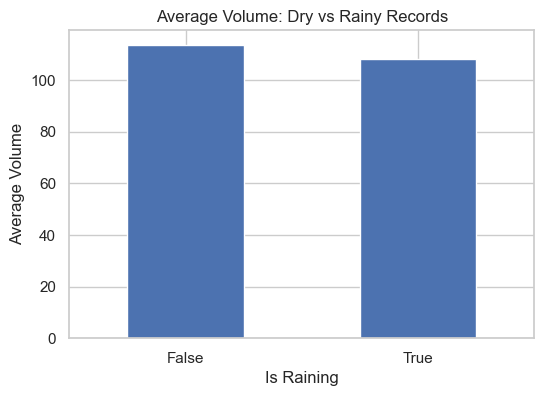

In [59]:
weather_summary = eda_df.groupby("is_raining").agg(
    records=("vol", "size"),
    avg_volume=("vol", "mean"),
    median_volume=("vol", "median"),
    avg_temperature=("temperature_2m", "mean"),
    avg_precipitation=("precipitation", "mean")
)

display(weather_summary)
weather_summary["avg_volume"].plot(kind="bar", figsize=(6, 4), title="Average Volume: Dry vs Rainy Records")
plt.xlabel("Is Raining")
plt.ylabel("Average Volume")
plt.xticks(rotation=0)
plt.show()

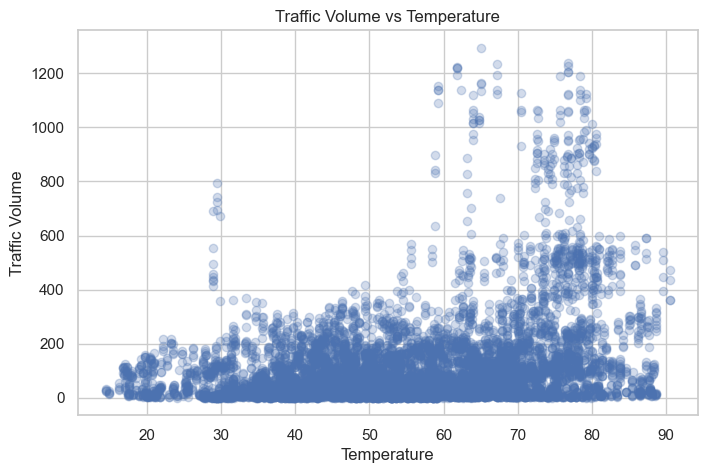

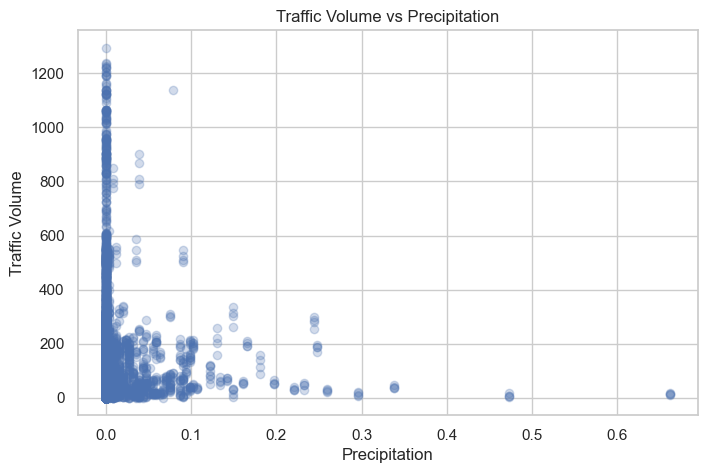

,vol,temperature_2m,precipitation,hour
vol,1.000000,0.303326,-0.022166,0.183205
temperature_2m,0.303326,1.000000,-0.004705,0.194206
precipitation,-0.022166,-0.004705,1.000000,0.000879
hour,0.183205,0.194206,0.000879,1.000000


In [60]:
plt.figure(figsize=(8, 5))
plt.scatter(eda_df["temperature_2m"], eda_df["vol"], alpha=0.25)
plt.title("Traffic Volume vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Traffic Volume")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(eda_df["precipitation"], eda_df["vol"], alpha=0.25)
plt.title("Traffic Volume vs Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Traffic Volume")
plt.show()

display(eda_df[["vol", "temperature_2m", "precipitation", "hour"]].corr())

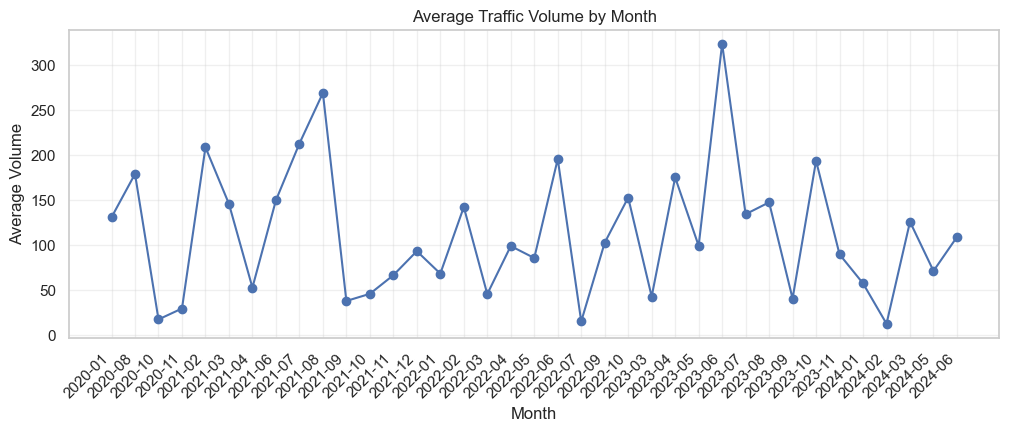

,month,vol
25,2023-05,99.156522
26,2023-06,323.051322
27,2023-07,134.166667
28,2023-08,147.313131
29,2023-09,40.676190
30,2023-10,193.382812
31,2023-11,89.619048
32,2024-01,57.485714
33,2024-02,12.756757
34,2024-03,125.752381


In [61]:
monthly_pattern = eda_df.groupby("month", as_index=False)["vol"].mean()

plt.figure(figsize=(12, 4))
plt.plot(monthly_pattern["month"], monthly_pattern["vol"], marker="o")
plt.title("Average Traffic Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.show()

display(monthly_pattern.tail(12))

In [62]:
if "engine" in globals():
    sql_check = pd.read_sql("""
        SELECT
            boro,
            COUNT(*) AS records,
            AVG(vol) AS avg_volume,
            AVG(temperature_2m) AS avg_temperature,
            AVG(precipitation) AS avg_precipitation
        FROM weather_traffic_full
        GROUP BY boro
        ORDER BY avg_volume DESC
    """, con=engine)
    display(sql_check)
else:
    print("MySQL engine is not defined yet. Run the database connection cell first to query from MySQL.")

,boro,records,avg_volume,avg_temperature,avg_precipitation
0,Brooklyn,2780,150.6295,58.024989,0.001684
1,Manhattan,1306,135.8438,51.967320,0.003777
2,Staten Island,315,130.7111,37.370000,0.000550
3,Queens,2586,94.0139,56.877413,0.009798
4,Bronx,1789,61.8932,55.694299,0.006624


### Initial EDA Takeaways

Use the tables and charts above to write your findings. Focus on the busiest hours, borough differences, the busiest streets, whether rainy records have lower or higher traffic volume, and whether temperature or precipitation has a visible relationship with traffic volume.

## 7. ML Pipeline: Full-Day Weather and Traffic Delay Regression

Research focus: **How do weather conditions impact traffic delays and transportation patterns in NYC?**

The source data does not include measured travel-time delay, so this pipeline creates a delay proxy from traffic volume behavior. To avoid rush-hour bias, the weather analysis and model use the full dataset. Rush hour is kept as a segment/feature, not as a filter that removes off-peak traffic.


### Research Questions

1. What is the relationship between precipitation and estimated delay time across the full day?
2. Does adding weather improve delay-time regression after the model already knows traffic volume, time, and location?
3. Does rain make traffic worse compared with dry conditions at the same hour/time block?
4. Which boroughs and rain intensities show the largest transportation pattern changes?
5. What tables support the required dashboards: live predictions, city comparison, and A/B results?


In [63]:
ml_df = eda_df.copy()

import seaborn as sns
sns.set_theme(style="whitegrid")

ml_df["rush_hour"] = ml_df["hour"].between(7, 10) | ml_df["hour"].between(16, 19)
ml_df["time_block"] = pd.cut(
    ml_df["hour"],
    bins=[-0.001, 5, 10, 15, 19, 23],
    labels=["overnight", "morning", "midday", "evening", "night"]
)
ml_df["rain_intensity"] = pd.cut(
    ml_df["precipitation"],
    bins=[-0.001, 0, 0.05, 0.15, float("inf")],
    labels=["none", "light", "moderate", "heavy"]
)

baseline_cols = ["boro", "street", "fromst", "tost", "direction", "day_of_week", "hour"]
traffic_baseline = (
    ml_df.groupby(baseline_cols)["vol"]
    .agg(
        expected_volume="median",
        p75_volume=lambda x: x.quantile(0.75),
        p90_volume=lambda x: x.quantile(0.90),
        volume_iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
        baseline_std="std",
        baseline_records="size"
    )
    .reset_index()
)

ml_df = ml_df.merge(traffic_baseline, on=baseline_cols, how="left")
ml_df = ml_df[ml_df["expected_volume"] > 0].copy()

ml_df["volume_ratio"] = ml_df["vol"] / ml_df["expected_volume"]
ml_df["volume_delta"] = ml_df["vol"] - ml_df["expected_volume"]
ml_df["delay_index"] = ml_df["volume_ratio"]

fallback_spread = ml_df["expected_volume"].clip(lower=1) * 0.25
spread = ml_df["volume_iqr"].where(ml_df["volume_iqr"] > 0, fallback_spread)
ml_df["congestion_score"] = (ml_df["volume_delta"] / spread).replace([float("inf"), -float("inf")], 0).fillna(0)

ml_df["is_moderate_congestion"] = ml_df["vol"] >= ml_df["p75_volume"]
ml_df["is_volume_spike"] = ml_df["vol"] >= ml_df["p90_volume"]
ml_df["weather_pressure"] = (
    (ml_df["precipitation"] > 0).astype(int)
    + (ml_df["precipitation"] >= 0.05).astype(int)
    + (ml_df["precipitation"] >= 0.15).astype(int)
)

ml_df["delay_score"] = (
    ml_df["congestion_score"].clip(lower=0)
    + 0.25 * ml_df["is_moderate_congestion"].astype(int)
    + 0.50 * ml_df["is_volume_spike"].astype(int)
    + 0.25 * ml_df["weather_pressure"]
)

# Delay-time proxy: convert the simpler volume-ratio target into estimated excess minutes.
# A ratio of 1.20 means traffic is 20% above its local baseline, or about 12 excess minutes.
ml_df["delay_minutes"] = ((ml_df["volume_ratio"].clip(lower=1) - 1) * 60).round(2)
ml_df["delay_level"] = pd.cut(
    ml_df["delay_minutes"],
    bins=[-0.001, 5, 15, 30, float("inf")],
    labels=["Low", "Moderate", "High", "Severe"]
)

analysis_df = ml_df.copy()
rush_df = ml_df[ml_df["rush_hour"]].copy()

print(f"Full-day rows: {len(analysis_df):,}")
print(f"Rush-hour rows retained as segment: {len(rush_df):,}")
print(f"Average estimated delay minutes, full day: {analysis_df['delay_minutes'].mean():.2f}")
print(f"Average precipitation, full day: {analysis_df['precipitation'].mean():.3f}")
display(analysis_df[[
    "date", "hour", "time_block", "rush_hour", "boro", "street", "vol", "expected_volume", "volume_ratio",
    "volume_delta", "congestion_score", "is_volume_spike", "weather_pressure",
    "delay_score", "delay_minutes", "delay_level", "temperature_2m", "precipitation", "rain_intensity"
]].head())


Full-day rows: 8,639
Rush-hour rows retained as segment: 2,875
Average estimated delay minutes, full day: 5.75
Average precipitation, full day: 0.005


,date,hour,time_block,rush_hour,boro,street,vol,expected_volume,volume_ratio,volume_delta,congestion_score,is_volume_spike,weather_pressure,delay_score,delay_minutes,delay_level,temperature_2m,precipitation,rain_intensity
0,2023-11-15,20,night,False,Brooklyn,AVENUE J,20,20.0,1.000000,0.0,0.000000,True,0,0.750000,0.00,Low,45.139999,0.0,none
1,2023-11-15,21,night,False,Brooklyn,AVENUE J,15,19.0,0.789474,-4.0,-0.432432,False,0,0.000000,0.00,Low,45.950001,0.0,none
2,2023-11-15,21,night,False,Brooklyn,AVENUE J,26,19.0,1.368421,7.0,0.756757,True,0,1.506757,22.11,High,45.950001,0.0,none
3,2023-11-15,21,night,False,Brooklyn,AVENUE J,23,19.0,1.210526,4.0,0.432432,False,0,0.432432,12.63,Moderate,45.950001,0.0,none
4,2023-11-15,21,night,False,Brooklyn,AVENUE J,13,19.0,0.684211,-6.0,-0.648649,False,0,0.000000,0.00,Low,45.950001,0.0,none


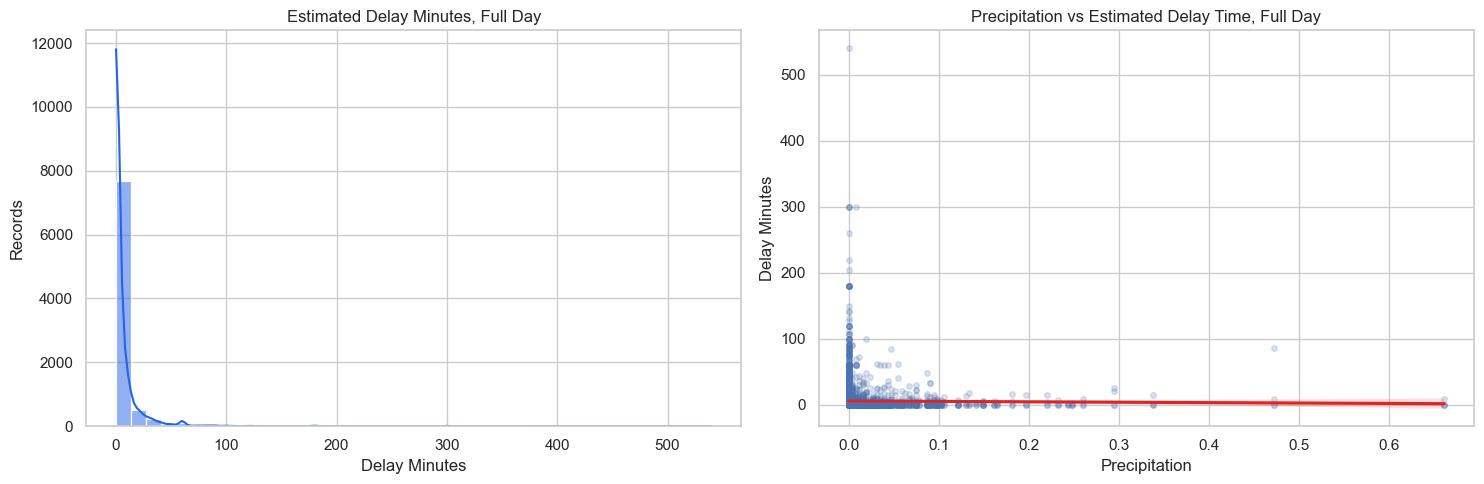

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(analysis_df["delay_minutes"], bins=40, kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Estimated Delay Minutes, Full Day")
axes[0].set_xlabel("Delay Minutes")
axes[0].set_ylabel("Records")

sns.regplot(
    data=analysis_df,
    x="precipitation",
    y="delay_minutes",
    scatter_kws={"alpha": 0.20, "s": 16},
    line_kws={"color": "#dc2626"},
    ax=axes[1]
)
axes[1].set_title("Precipitation vs Estimated Delay Time, Full Day")
axes[1].set_xlabel("Precipitation")
axes[1].set_ylabel("Delay Minutes")

plt.tight_layout()
plt.show()


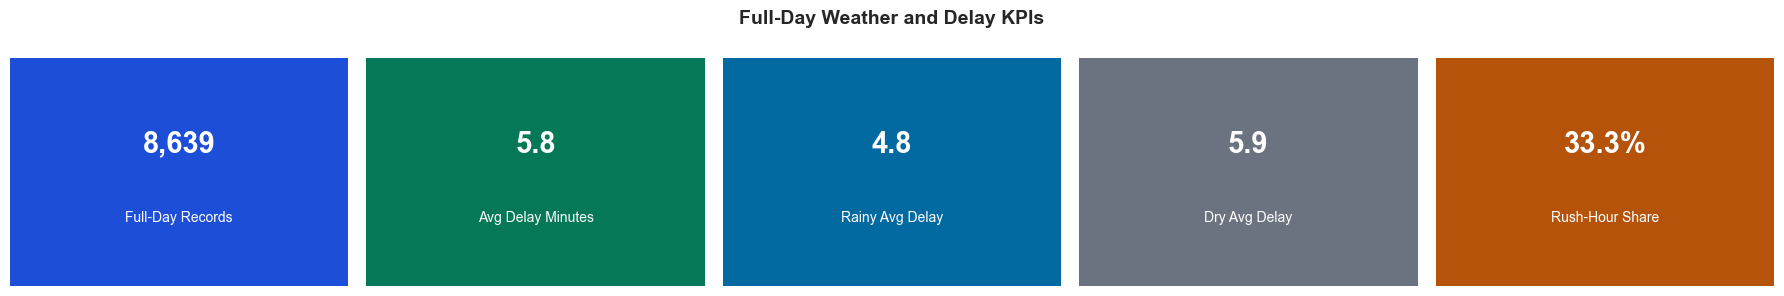

In [65]:
rainy_mask = analysis_df["is_raining"].astype(str).str.lower().eq("true")
dry_mask = ~rainy_mask

kpi_values = {
    "Full-Day Records": f"{len(analysis_df):,}",
    "Avg Delay Minutes": f"{analysis_df['delay_minutes'].mean():.1f}",
    "Rainy Avg Delay": f"{analysis_df.loc[rainy_mask, 'delay_minutes'].mean():.1f}" if rainy_mask.any() else "N/A",
    "Dry Avg Delay": f"{analysis_df.loc[dry_mask, 'delay_minutes'].mean():.1f}" if dry_mask.any() else "N/A",
    "Rush-Hour Share": f"{analysis_df['rush_hour'].mean():.1%}"
}

fig, axes = plt.subplots(1, len(kpi_values), figsize=(18, 3))
card_colors = ["#1d4ed8", "#047857", "#0369a1", "#6b7280", "#b45309"]

for ax, (label, value), color in zip(axes, kpi_values.items(), card_colors):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=21, color="white", fontweight="bold")
    ax.text(0.5, 0.30, label, ha="center", va="center", fontsize=10, color="white")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle("Full-Day Weather and Delay KPIs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


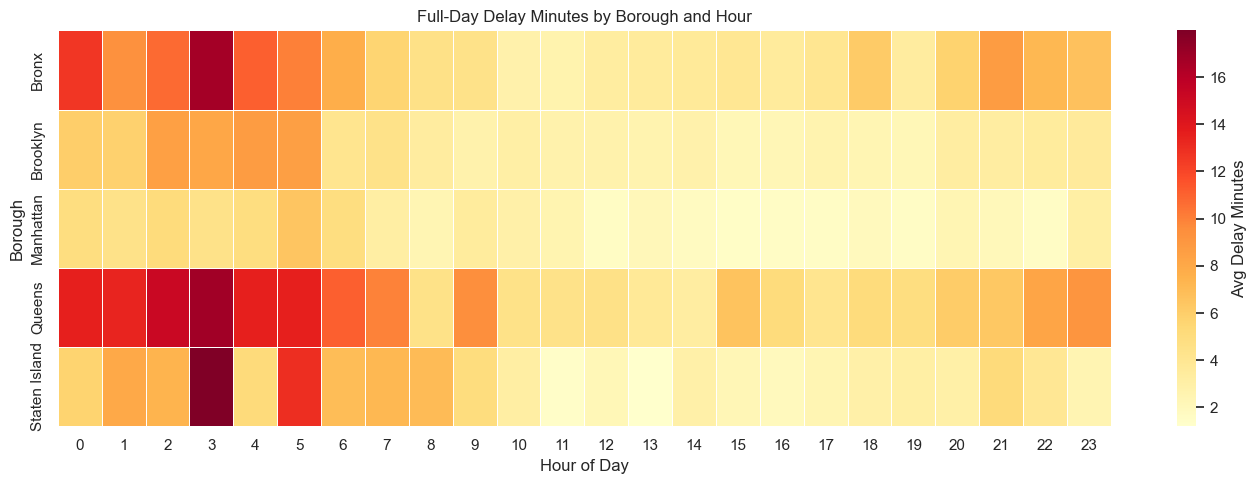

In [66]:
delay_heatmap = analysis_df.pivot_table(
    index="boro",
    columns="hour",
    values="delay_minutes",
    aggfunc="mean"
)

plt.figure(figsize=(14, 5))
sns.heatmap(
    delay_heatmap,
    annot=False,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Avg Delay Minutes"}
)
plt.title("Full-Day Delay Minutes by Borough and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()


In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

baseline_features = ["hour", "boro", "street", "direction", "day_of_week", "time_block", "rush_hour"]
weather_features = baseline_features + ["temperature_2m", "precipitation", "is_raining", "rain_intensity"]
target = "volume_ratio"

categorical_cleanup_cols = ["boro", "street", "direction", "day_of_week", "time_block", "rush_hour", "is_raining", "rain_intensity"]
for col in categorical_cleanup_cols:
    analysis_df[col] = analysis_df[col].astype("object").where(analysis_df[col].notna(), "missing").astype(str)

numeric_lookup = ["hour", "temperature_2m", "precipitation"]

target_diagnostics = pd.DataFrame({
    "metric": ["mean", "std", "min", "max"],
    "volume_ratio": [
        analysis_df[target].mean(),
        analysis_df[target].std(),
        analysis_df[target].min(),
        analysis_df[target].max()
    ]
})
print("Target diagnostics, full-day volume ratio:")
display(target_diagnostics)
display(analysis_df[["date", "hour", "time_block", "rush_hour", "boro", "street", "vol", "expected_volume", target]].head(10))

correlation_rows = []
for col in numeric_lookup:
    correlation_rows.append({
        "feature": col,
        "correlation_with_volume_ratio": analysis_df[[col, target]].corr().iloc[0, 1]
    })
feature_correlations = pd.DataFrame(correlation_rows).sort_values(
    "correlation_with_volume_ratio",
    key=lambda series: series.abs(),
    ascending=False
)
print("Numeric feature-target correlations, full day:")
display(feature_correlations)

def build_regression_model(feature_cols):
    numeric_features = [col for col in feature_cols if col in numeric_lookup]
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=15,
            min_samples_split=30,
            max_features="sqrt",
            random_state=42
        ))
    ])

X_train, X_test, y_train, y_test = train_test_split(
    analysis_df[weather_features],
    analysis_df[target],
    test_size=0.25,
    random_state=42
)

baseline_model = build_regression_model(baseline_features)
weather_model = build_regression_model(weather_features)

baseline_model.fit(X_train[baseline_features], y_train)
weather_model.fit(X_train[weather_features], y_train)

def ratio_to_delay_minutes(predicted_ratio):
    return ((pd.Series(predicted_ratio).clip(lower=1) - 1) * 60).round(2)

def evaluate_predictions(name, features, ab_group, pred):
    return {
        "model": name,
        "target": target,
        "features": features,
        "mae": mean_absolute_error(y_test, pred),
        "rmse": mean_squared_error(y_test, pred) ** 0.5,
        "r2": r2_score(y_test, pred),
        "ab_group": ab_group
    }

mean_prediction = pd.Series(y_train.mean(), index=y_test.index)
baseline_pred = pd.Series(
    baseline_model.predict(X_test[baseline_features]).clip(min=0),
    index=y_test.index
)
weather_pred = pd.Series(
    weather_model.predict(X_test[weather_features]).clip(min=0),
    index=y_test.index
)

model_results = pd.DataFrame([
    evaluate_predictions("mean_volume_ratio_benchmark", "train_mean_only", "Benchmark: mean", mean_prediction),
    evaluate_predictions("baseline_time_location", "time_location", "A: baseline", baseline_pred),
    evaluate_predictions("precipitation_aware", "time_location_weather_precipitation", "B: precipitation-aware", weather_pred)
])

display(model_results)

pred_compare = X_test.copy()
pred_compare["actual_volume_ratio"] = y_test
pred_compare["mean_predicted_volume_ratio"] = mean_prediction
pred_compare["baseline_predicted_volume_ratio"] = baseline_pred
pred_compare["weather_predicted_volume_ratio"] = weather_pred
pred_compare["weather_predicted_delay_minutes"] = ratio_to_delay_minutes(weather_pred).values
display(pred_compare[["hour", "time_block", "rush_hour", "boro", "precipitation", "rain_intensity", "actual_volume_ratio", "mean_predicted_volume_ratio", "baseline_predicted_volume_ratio", "weather_predicted_volume_ratio", "weather_predicted_delay_minutes"]].head())


Target diagnostics, full-day volume ratio:


,metric,volume_ratio
0,mean,1.019615
1,std,0.335609
2,min,0.000000
3,max,10.000000


,date,hour,time_block,rush_hour,boro,street,vol,expected_volume,volume_ratio
0,2023-11-15,20,night,False,Brooklyn,AVENUE J,20,20.0,1.000000
1,2023-11-15,21,night,False,Brooklyn,AVENUE J,15,19.0,0.789474
2,2023-11-15,21,night,False,Brooklyn,AVENUE J,26,19.0,1.368421
3,2023-11-15,21,night,False,Brooklyn,AVENUE J,23,19.0,1.210526
4,2023-11-15,21,night,False,Brooklyn,AVENUE J,13,19.0,0.684211
5,2023-11-15,22,night,False,Brooklyn,AVENUE J,17,14.5,1.172414
6,2023-11-15,22,night,False,Brooklyn,AVENUE J,15,14.5,1.034483
7,2023-11-15,22,night,False,Brooklyn,AVENUE J,14,14.5,0.965517
8,2023-11-15,22,night,False,Brooklyn,AVENUE J,8,14.5,0.551724
9,2023-11-15,23,night,False,Brooklyn,AVENUE J,11,10.0,1.100000


Numeric feature-target correlations, full day:


,feature,correlation_with_volume_ratio
0,hour,-0.040855
1,temperature_2m,-0.018311
2,precipitation,-0.006686


,model,target,features,mae,rmse,r2,ab_group
0,mean_volume_ratio_benchmark,volume_ratio,train_mean_only,0.181466,0.321285,-0.000529,Benchmark: mean
1,baseline_time_location,volume_ratio,time_location,0.184619,0.324678,-0.021774,A: baseline
2,precipitation_aware,volume_ratio,time_location_weather_precipitation,0.185170,0.326167,-0.031168,B: precipitation-aware


,hour,time_block,rush_hour,boro,precipitation,rain_intensity,actual_volume_ratio,mean_predicted_volume_ratio,baseline_predicted_volume_ratio,weather_predicted_volume_ratio,weather_predicted_delay_minutes
7174,23,night,False,Bronx,0.055118,moderate,1.083333,1.021462,1.019168,1.014218,0.85
4453,11,midday,False,Brooklyn,0.000000,none,0.694444,1.021462,0.999311,1.003332,0.20
222,21,night,False,Manhattan,0.000000,none,1.049919,1.021462,0.998453,1.001564,0.09
4148,20,night,False,Manhattan,0.000000,none,0.974895,1.021462,1.003007,1.000999,0.06
318,13,midday,False,Brooklyn,0.000000,none,0.919149,1.021462,1.003465,1.004315,0.26


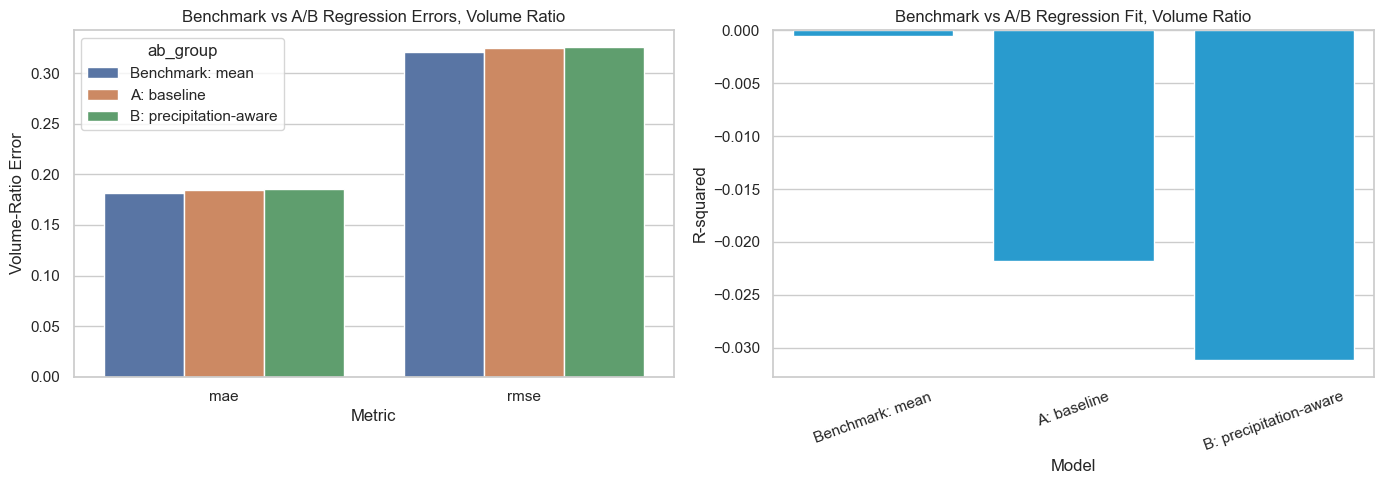

,precipitation_model_minus_baseline
mae,0.000551
rmse,0.001489
r2,-0.009394


In [68]:
model_results_long = model_results.melt(
    id_vars=["model", "target", "features", "ab_group"],
    value_vars=["mae", "rmse", "r2"],
    var_name="metric",
    value_name="score"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
error_metrics = model_results_long[model_results_long["metric"].isin(["mae", "rmse"])]
sns.barplot(data=error_metrics, x="metric", y="score", hue="ab_group", ax=axes[0])
axes[0].set_title("Benchmark vs A/B Regression Errors, Volume Ratio")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Volume-Ratio Error")

sns.barplot(data=model_results, x="ab_group", y="r2", ax=axes[1], color="#0ea5e9")
axes[1].set_title("Benchmark vs A/B Regression Fit, Volume Ratio")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("R-squared")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

ab_lift = model_results.set_index("model").loc["precipitation_aware", ["mae", "rmse", "r2"]] - model_results.set_index("model").loc["baseline_time_location", ["mae", "rmse", "r2"]]
display(ab_lift.to_frame("precipitation_model_minus_baseline"))


In [69]:
feature_names = weather_model.named_steps["preprocessor"].get_feature_names_out()
importances = weather_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

importance_df["clean_feature"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

precip_importance = importance_df[importance_df["clean_feature"].str.contains("precipitation|is_raining|rain_intensity", regex=True)]
print(f"Combined precipitation feature importance: {precip_importance['importance'].sum():.3f}")
display(importance_df.head(20))
display(precip_importance)


Combined precipitation feature importance: 0.038


,feature,importance,clean_feature
1,num__temperature_2m,0.182282,temperature_2m
0,num__hour,0.134065,hour
10,cat__street_218 PLACE,0.077710,street_218 PLACE
93,cat__time_block_overnight,0.056954,time_block_overnight
41,cat__street_EAST 179 STREET,0.037987,street_EAST 179 STREET
6,cat__boro_Queens,0.037649,boro_Queens
80,cat__direction_SB,0.022345,direction_SB
61,cat__street_MARCONI STREET,0.021971,street_MARCONI STREET
37,cat__street_CODY AVENUE,0.019937,street_CODY AVENUE
86,cat__day_of_week_Thursday,0.019739,day_of_week_Thursday


,feature,importance,clean_feature
2,num__precipitation,0.015720,precipitation
96,cat__is_raining_False,0.007947,is_raining_False
97,cat__is_raining_True,0.004883,is_raining_True
101,cat__rain_intensity_none,0.004272,rain_intensity_none
99,cat__rain_intensity_light,0.003313,rain_intensity_light
100,cat__rain_intensity_moderate,0.001440,rain_intensity_moderate
98,cat__rain_intensity_heavy,0.000394,rain_intensity_heavy


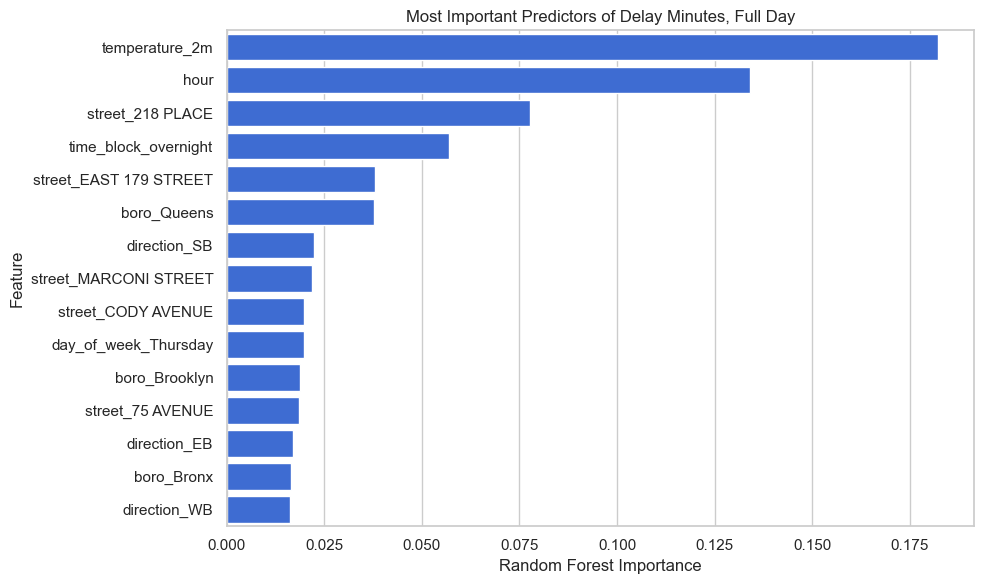

In [70]:
top_importance = importance_df.head(15).copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_importance, x="importance", y="clean_feature", color="#2563eb")
plt.title("Most Important Predictors of Delay Minutes, Full Day")
plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [71]:
rain_effect = analysis_df.groupby("rain_intensity", observed=True).agg(
    records=("delay_minutes", "size"),
    avg_delay_minutes=("delay_minutes", "mean"),
    median_delay_minutes=("delay_minutes", "median"),
    avg_delay_index=("delay_index", "mean"),
    avg_volume=("vol", "mean"),
    avg_precipitation=("precipitation", "mean")
).reset_index()

hour_rain_effect = analysis_df.groupby(["hour", "rain_intensity"], observed=True).agg(
    records=("delay_minutes", "size"),
    avg_delay_minutes=("delay_minutes", "mean"),
    avg_precipitation=("precipitation", "mean")
).reset_index()

boro_rain_effect = analysis_df.groupby(["boro", "rain_intensity"], observed=True).agg(
    records=("delay_minutes", "size"),
    avg_delay_minutes=("delay_minutes", "mean"),
    avg_delay_index=("delay_index", "mean"),
    avg_volume=("vol", "mean"),
    avg_precipitation=("precipitation", "mean")
).reset_index().sort_values("avg_delay_minutes", ascending=False)

dry_by_hour = hour_rain_effect[hour_rain_effect["rain_intensity"].astype(str) == "none"][["hour", "avg_delay_minutes"]].rename(columns={"avg_delay_minutes": "dry_avg_delay_minutes"})
hour_rain_lift = hour_rain_effect.merge(dry_by_hour, on="hour", how="left")
hour_rain_lift["delay_lift_vs_same_hour_dry"] = hour_rain_lift["avg_delay_minutes"] - hour_rain_lift["dry_avg_delay_minutes"]

display(rain_effect)
display(hour_rain_lift.sort_values("delay_lift_vs_same_hour_dry", ascending=False).head(20))
display(boro_rain_effect.head(20))


,rain_intensity,records,avg_delay_minutes,median_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
0,heavy,52,5.078462,0.0,1.013747,83.000000,0.282859
1,light,852,5.062488,0.0,1.011381,111.892019,0.015485
2,moderate,222,3.899550,0.0,1.002183,101.522523,0.085426
3,none,7513,5.891292,0.0,1.021104,115.663650,0.000000


,hour,rain_intensity,records,avg_delay_minutes,avg_precipitation,dry_avg_delay_minutes,delay_lift_vs_same_hour_dry
8,2,heavy,4,23.570000,0.472441,10.328875,13.241125
32,9,light,49,9.643673,0.013418,4.614448,5.029226
20,5,moderate,8,15.000000,0.082677,10.034286,4.965714
82,23,moderate,7,9.832857,0.055118,5.856581,3.976276
33,9,moderate,8,8.303750,0.080709,4.614448,3.689302
74,21,moderate,8,8.657500,0.053150,5.304032,3.353468
9,2,light,20,12.869000,0.014173,10.328875,2.540125
0,0,heavy,4,11.785000,0.295276,9.788118,1.996882
23,6,moderate,4,9.000000,0.066929,7.175685,1.824315
16,4,light,48,11.314167,0.022638,9.671026,1.643141


,boro,rain_intensity,records,avg_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
14,Queens,none,2111,8.524912,1.043658,96.816201,0.000000
12,Queens,light,297,7.850000,1.021429,97.282828,0.014608
3,Bronx,none,1474,7.048440,1.027364,57.474220,0.000000
11,Queens,heavy,36,6.468056,1.016487,42.583333,0.311024
16,Staten Island,none,303,5.273729,1.008379,129.960396,0.000000
13,Queens,moderate,116,4.616552,1.001146,71.612069,0.083560
1,Bronx,light,210,4.337333,1.011460,87.523810,0.021785
6,Brooklyn,none,2531,4.249905,1.009043,151.716318,0.000000
5,Brooklyn,moderate,18,3.810000,1.001693,180.444444,0.094051
2,Bronx,moderate,61,3.314590,1.006220,97.672131,0.077707


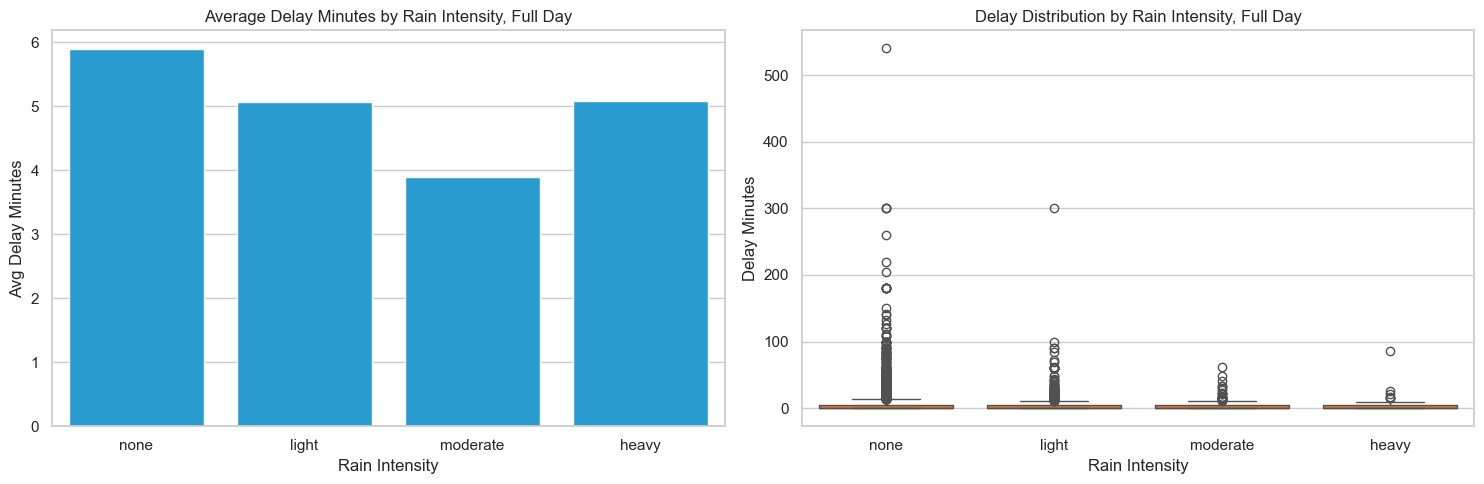

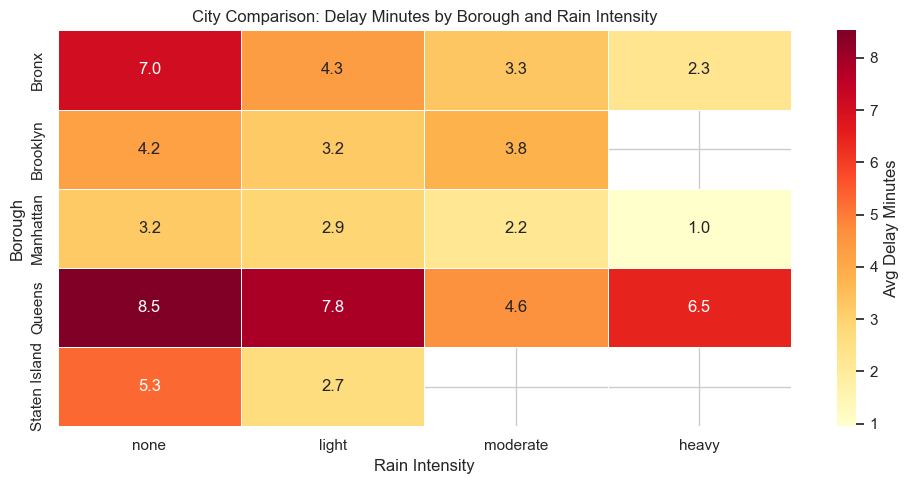

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rain_order = ["none", "light", "moderate", "heavy"]
sns.barplot(data=rain_effect, x="rain_intensity", y="avg_delay_minutes", order=rain_order, ax=axes[0], color="#0ea5e9")
axes[0].set_title("Average Delay Minutes by Rain Intensity, Full Day")
axes[0].set_xlabel("Rain Intensity")
axes[0].set_ylabel("Avg Delay Minutes")

sns.boxplot(data=analysis_df, x="rain_intensity", y="delay_minutes", order=rain_order, ax=axes[1], color="#f97316")
axes[1].set_title("Delay Distribution by Rain Intensity, Full Day")
axes[1].set_xlabel("Rain Intensity")
axes[1].set_ylabel("Delay Minutes")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(
    boro_rain_effect.pivot(index="boro", columns="rain_intensity", values="avg_delay_minutes").reindex(columns=rain_order),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Avg Delay Minutes"}
)
plt.title("City Comparison: Delay Minutes by Borough and Rain Intensity")
plt.xlabel("Rain Intensity")
plt.ylabel("Borough")
plt.tight_layout()
plt.show()


In [73]:
scored_df = analysis_df.copy()
scored_df["predicted_volume_ratio"] = weather_model.predict(scored_df[weather_features]).clip(min=0)
scored_df["predicted_delay_minutes"] = ratio_to_delay_minutes(scored_df["predicted_volume_ratio"]).values
scored_df["prediction_error_volume_ratio"] = scored_df["volume_ratio"] - scored_df["predicted_volume_ratio"]
scored_df["prediction_error_minutes"] = scored_df["delay_minutes"] - scored_df["predicted_delay_minutes"]
scored_df["delay_level"] = pd.cut(
    scored_df["predicted_delay_minutes"],
    bins=[-0.001, 5, 15, 30, float("inf")],
    labels=["Low", "Moderate", "High", "Severe"]
)

precip_thresholds = sorted(scored_df["precipitation"].dropna().unique())
precip_thresholds = [x for x in precip_thresholds if x > 0]

threshold_rows = []
for threshold in precip_thresholds:
    lower = scored_df[scored_df["precipitation"] < threshold]
    upper = scored_df[scored_df["precipitation"] >= threshold]
    if len(lower) >= 100 and len(upper) >= 100:
        threshold_rows.append({
            "precipitation_threshold": threshold,
            "below_avg_predicted_volume_ratio": lower["predicted_volume_ratio"].mean(),
            "above_avg_predicted_volume_ratio": upper["predicted_volume_ratio"].mean(),
            "volume_ratio_jump": upper["predicted_volume_ratio"].mean() - lower["predicted_volume_ratio"].mean(),
            "below_avg_predicted_delay_minutes": lower["predicted_delay_minutes"].mean(),
            "above_avg_predicted_delay_minutes": upper["predicted_delay_minutes"].mean(),
            "delay_minute_jump": upper["predicted_delay_minutes"].mean() - lower["predicted_delay_minutes"].mean(),
            "below_records": len(lower),
            "above_records": len(upper)
        })

precip_tipping = pd.DataFrame(
    threshold_rows,
    columns=[
        "precipitation_threshold",
        "below_avg_predicted_volume_ratio",
        "above_avg_predicted_volume_ratio",
        "volume_ratio_jump",
        "below_avg_predicted_delay_minutes",
        "above_avg_predicted_delay_minutes",
        "delay_minute_jump",
        "below_records",
        "above_records",
    ]
).sort_values("volume_ratio_jump", ascending=False)
display(precip_tipping.head(10))

display(scored_df[["date", "hour", "time_block", "rush_hour", "boro", "street", "precipitation", "rain_intensity", "volume_ratio", "predicted_volume_ratio", "predicted_delay_minutes", "delay_level"]].head())


,precipitation_threshold,below_avg_predicted_volume_ratio,above_avg_predicted_volume_ratio,volume_ratio_jump,below_avg_predicted_delay_minutes,above_avg_predicted_delay_minutes,delay_minute_jump,below_records,above_records
1,0.007874,1.023476,1.015280,-0.008196,1.434079,1.039224,-0.394855,7788,851
0,0.003937,1.023761,1.015378,-0.008383,1.450125,1.028597,-0.421528,7513,1126
2,0.011811,1.023540,1.012880,-0.010660,1.438235,0.911431,-0.526805,7933,706
3,0.015748,1.023541,1.011525,-0.012016,1.438542,0.841132,-0.597410,8012,627
4,0.019685,1.023512,1.010111,-0.013401,1.436793,0.776011,-0.660782,8095,544
5,0.023622,1.023492,1.009210,-0.014281,1.435720,0.732510,-0.703210,8141,498
7,0.031496,1.023373,1.009049,-0.014324,1.428402,0.753176,-0.675225,8214,425
6,0.027559,1.023447,1.009023,-0.014424,1.432943,0.732940,-0.700003,8173,466
8,0.035433,1.023389,1.007678,-0.015711,1.429301,0.685000,-0.744301,8243,396
9,0.039370,1.023403,1.006124,-0.017278,1.430045,0.609428,-0.820617,8272,367


,date,hour,time_block,rush_hour,boro,street,precipitation,rain_intensity,volume_ratio,predicted_volume_ratio,predicted_delay_minutes,delay_level
0,2023-11-15,20,night,False,Brooklyn,AVENUE J,0.0,none,1.000000,0.997012,0.0,Low
1,2023-11-15,21,night,False,Brooklyn,AVENUE J,0.0,none,0.789474,0.996137,0.0,Low
2,2023-11-15,21,night,False,Brooklyn,AVENUE J,0.0,none,1.368421,0.996137,0.0,Low
3,2023-11-15,21,night,False,Brooklyn,AVENUE J,0.0,none,1.210526,0.996137,0.0,Low
4,2023-11-15,21,night,False,Brooklyn,AVENUE J,0.0,none,0.684211,0.996137,0.0,Low


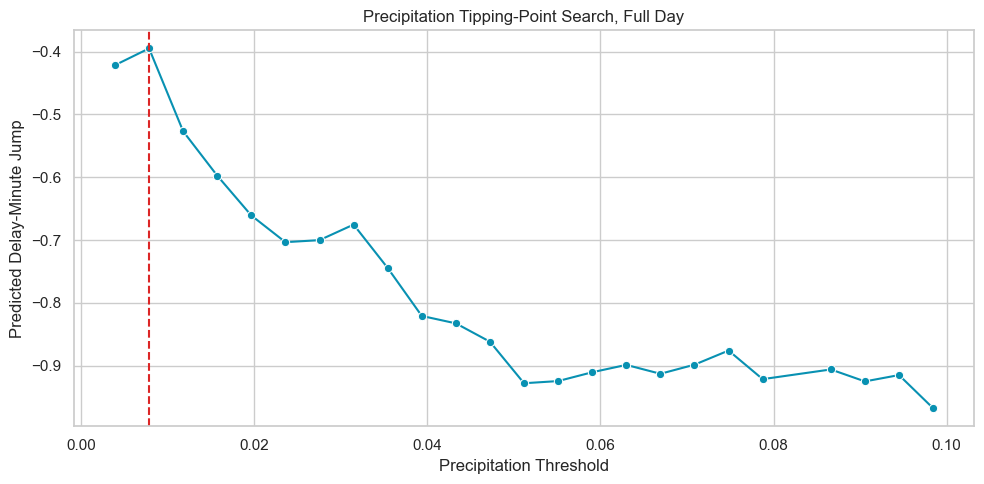

In [74]:
plt.figure(figsize=(10, 5))

if len(precip_tipping):
    precip_plot = precip_tipping.sort_values("precipitation_threshold")
    sns.lineplot(data=precip_plot, x="precipitation_threshold", y="delay_minute_jump", marker="o", color="#0891b2")
    best_precip = precip_tipping.iloc[0]
    plt.axvline(best_precip["precipitation_threshold"], color="#dc2626", linestyle="--")
    plt.title("Precipitation Tipping-Point Search, Full Day")
    plt.xlabel("Precipitation Threshold")
    plt.ylabel("Predicted Delay-Minute Jump")
else:
    plt.text(0.5, 0.5, "No reliable precipitation tipping point", ha="center", va="center")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [75]:
benchmark_metrics = model_results.set_index("model").loc["mean_volume_ratio_benchmark"]
baseline_metrics = model_results.set_index("model").loc["baseline_time_location"]
precip_metrics = model_results.set_index("model").loc["precipitation_aware"]

baseline_rmse_vs_mean = baseline_metrics["rmse"] - benchmark_metrics["rmse"]
precip_rmse_vs_baseline = precip_metrics["rmse"] - baseline_metrics["rmse"]
precip_mae_vs_baseline = precip_metrics["mae"] - baseline_metrics["mae"]
precip_r2_vs_baseline = precip_metrics["r2"] - baseline_metrics["r2"]
best_precip_threshold = precip_tipping.iloc[0] if len(precip_tipping) else None

print("Q1: What is the relationship between precipitation and estimated delay time across the full day?")
display(rain_effect)

print("Q2: Does rain make traffic worse compared with dry conditions at the same hour?")
display(hour_rain_lift[hour_rain_lift["rain_intensity"].astype(str) != "none"].sort_values("delay_lift_vs_same_hour_dry", ascending=False).head(10))

print("Q3: Does the time/location baseline beat the mean volume-ratio benchmark?")
print(f"Baseline RMSE change vs mean benchmark: {baseline_rmse_vs_mean:.3f} volume-ratio points (negative is better)")
print(f"Baseline R-squared: {baseline_metrics['r2']:.3f}")

print("Q4: Does precipitation improve volume-ratio prediction after time/location are included?")
print(f"Precipitation model RMSE change vs baseline: {precip_rmse_vs_baseline:.3f} volume-ratio points (negative is better)")
print(f"Precipitation model MAE change vs baseline: {precip_mae_vs_baseline:.3f} volume-ratio points (negative is better)")
print(f"Precipitation model R-squared change vs baseline: {precip_r2_vs_baseline:.3f} (positive is better)")

print("Q5: Which weather condition creates the sharpest predicted congestion increase?")
if best_precip_threshold is not None:
    print(f"Strongest precipitation tipping candidate: >= {best_precip_threshold['precipitation_threshold']:.3f}, predicted volume-ratio jump {best_precip_threshold['volume_ratio_jump']:.3f}, delay jump {best_precip_threshold['delay_minute_jump']:.2f} minutes")
else:
    print("No reliable precipitation tipping point found with enough records on both sides.")

print("Dashboard mapping:")
print("1. Live/input predictions: scored_df and tableau_weather_time_scenarios")
print("2. City comparison: boro_rain_effect and tableau_city_comparison")
print("3. A/B results: model_results and tableau_ab_results")


Q1: What is the relationship between precipitation and estimated delay time across the full day?


,rain_intensity,records,avg_delay_minutes,median_delay_minutes,avg_delay_index,avg_volume,avg_precipitation
0,heavy,52,5.078462,0.0,1.013747,83.000000,0.282859
1,light,852,5.062488,0.0,1.011381,111.892019,0.015485
2,moderate,222,3.899550,0.0,1.002183,101.522523,0.085426
3,none,7513,5.891292,0.0,1.021104,115.663650,0.000000


Q2: Does rain make traffic worse compared with dry conditions at the same hour?


,hour,rain_intensity,records,avg_delay_minutes,avg_precipitation,dry_avg_delay_minutes,delay_lift_vs_same_hour_dry
8,2,heavy,4,23.570000,0.472441,10.328875,13.241125
32,9,light,49,9.643673,0.013418,4.614448,5.029226
20,5,moderate,8,15.000000,0.082677,10.034286,4.965714
82,23,moderate,7,9.832857,0.055118,5.856581,3.976276
33,9,moderate,8,8.303750,0.080709,4.614448,3.689302
74,21,moderate,8,8.657500,0.053150,5.304032,3.353468
9,2,light,20,12.869000,0.014173,10.328875,2.540125
0,0,heavy,4,11.785000,0.295276,9.788118,1.996882
23,6,moderate,4,9.000000,0.066929,7.175685,1.824315
16,4,light,48,11.314167,0.022638,9.671026,1.643141


Q3: Does the time/location baseline beat the mean volume-ratio benchmark?
Baseline RMSE change vs mean benchmark: 0.003 volume-ratio points (negative is better)
Baseline R-squared: -0.022
Q4: Does precipitation improve volume-ratio prediction after time/location are included?
Precipitation model RMSE change vs baseline: 0.001 volume-ratio points (negative is better)
Precipitation model MAE change vs baseline: 0.001 volume-ratio points (negative is better)
Precipitation model R-squared change vs baseline: -0.009 (positive is better)
Q5: Which weather condition creates the sharpest predicted congestion increase?
Strongest precipitation tipping candidate: >= 0.008, predicted volume-ratio jump -0.008, delay jump -0.39 minutes
Dashboard mapping:
1. Live/input predictions: scored_df and tableau_weather_time_scenarios
2. City comparison: boro_rain_effect and tableau_city_comparison
3. A/B results: model_results and tableau_ab_results


### Suggested Interpretation

Use `rain_effect` for full-day differences by rain intensity, and use `hour_rain_lift` to compare rainy conditions against dry conditions at the same hour. The model now predicts `volume_ratio`, a simpler congestion target, instead of predicting a composite delay score derived from volume. It does not use `vol` as a feature, avoiding circular prediction. Predicted delay minutes are derived afterward from predicted volume ratio for dashboard readability. Use `model_results` to compare the mean benchmark, Model A (time/location baseline), and Model B (time/location plus weather). Use `scored_df`, `boro_rain_effect`, and the Tableau export tables to build the required live/input predictions, city comparison, and A/B results dashboards.


## 8. Tableau Dashboard Tables

Create MySQL tables designed for the three required Tableau dashboards: **live predictions**, **city comparison**, and **A/B results**.


In [76]:
import importlib
import tableau_exports

importlib.reload(tableau_exports)
from tableau_exports import build_tableau_tables, write_tableau_tables

tableau_tables = build_tableau_tables(
    model_df=analysis_df,
    scored_df=scored_df,
    model_results=model_results,
    weather_features=weather_features,
    weather_model=weather_model,
    city_df=analysis_df
)

for table_name, table_df in tableau_tables.items():
    print(f"{table_name}: {table_df.shape[0]:,} rows x {table_df.shape[1]:,} columns")

display(tableau_tables["tableau_live_predictions"].head())
display(tableau_tables["tableau_city_comparison"].head())
display(tableau_tables["tableau_ab_results"])
display(tableau_tables["tableau_weather_time_scenarios"].head())

if "engine" in globals():
    written_tables = write_tableau_tables(engine, tableau_tables)
    print("Written to MySQL:")
    for table_name in written_tables:
        print(f"- {table_name}")
else:
    print("MySQL engine is not defined. Run the database connection cell before writing Tableau tables.")


TypeError: build_tableau_tables() got an unexpected keyword argument 'model_df'